# Taller de IA — Parte 4: Reto de visión en moda

En las partes 1–3 viste tres maneras de responder *¿qué hay en esta imagen?*: una red que **aprendes**, un QR que **decodificas**, un ArUco que **localizas**.

Aquí el dominio es **moda**. El dataset abierto es **Fashion-MNIST** (Zalando): 70,000 fotos 28×28 de prendas, mismas reglas que MNIST. Keras solo sirve para **cargarlo**. El reconocimiento lo haces tú con **OpenCV** (umbral, contornos, forma). Sin entrenar.

## Objetivo de esta parte

1. Ver el catálogo de 10 prendas
2. Extraer forma con OpenCV (contorno, caja, área, aspecto)
3. **Reto:** distinguir **calzado** vs **no calzado** y superar el baseline

No hay webcam. El extra del final es opcional.


## Paso 1: Preparar las herramientas

**Tarea**: Importar OpenCV, NumPy, Matplotlib y cargar Fashion-MNIST.

**Enfoque**: Keras aparece solo como descargador (`keras.datasets.fashion_mnist`), igual que MNIST en la Parte 1. OpenCV es el que analiza la prenda.


**Código**:

In [1]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

NOMBRES = [
    "Camiseta",
    "Pantalón",
    "Jersey",
    "Vestido",
    "Abrigo",
    "Sandalia",
    "Camisa",
    "Zapatilla",
    "Bolso",
    "Bota",
]
# Sandalia, zapatilla, bota.
CALZADO = {5, 7, 9}

print("OpenCV versión:", cv2.__version__)
print("Entrenamiento:", x_train.shape, "| prueba:", x_test.shape)
print("Clases:", ", ".join(f"{i}={n}" for i, n in enumerate(NOMBRES))
)


OpenCV versión: 5.0.0
Entrenamiento: (60000, 28, 28) | prueba: (10000, 28, 28)
Clases: 0=Camiseta, 1=Pantalón, 2=Jersey, 3=Vestido, 4=Abrigo, 5=Sandalia, 6=Camisa, 7=Zapatilla, 8=Bolso, 9=Bota


**Resultado**: 60,000 + 10,000 imágenes 28×28, diez nombres de prenda. `CALZADO` son las clases 5, 7 y 9.

Siguiente: mirar cómo se ve cada una.


## Paso 2: Mirar el catálogo

**Tarea**: Mostrar un ejemplo de cada clase.

**Enfoque**: Misma idea que los 16 dígitos de la Parte 1. Un pantalón es alto y estrecho; una zapatilla, más ancha que alta; un bolso, compacto. Esas formas son lo que OpenCV puede medir sin una red.


**Código**:

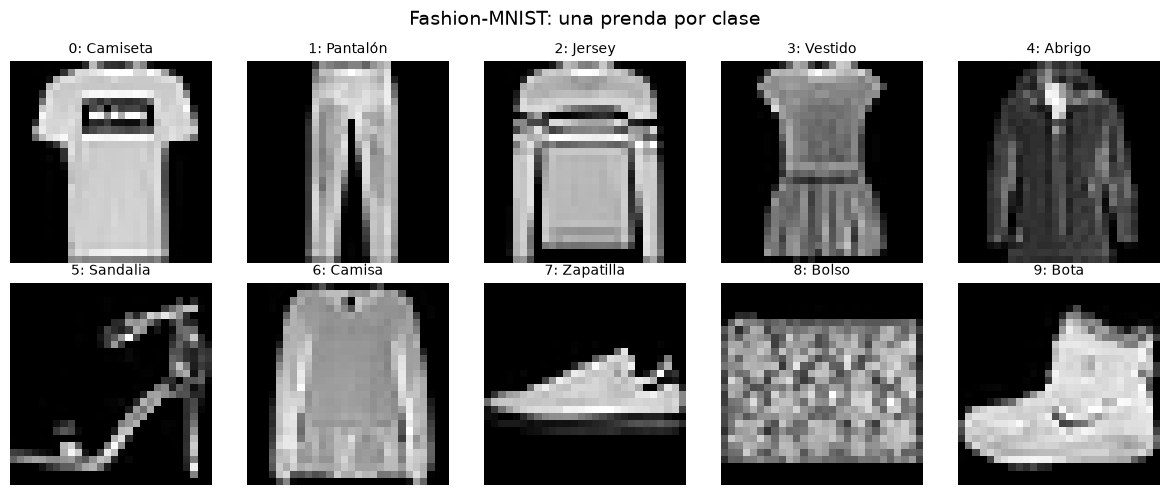

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for clase, ax in enumerate(axes.flat):
    idx = int(np.where(y_train == clase)[0][0])
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(f"{clase}: {NOMBRES[clase]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Fashion-MNIST: una prenda por clase", fontsize=14)
plt.tight_layout()
plt.show()


**Resultado**: Diez siluetas. El reto no pide las 10 clases: solo **calzado** (sandalia, zapatilla, bota) frente al resto.

Siguiente: el kit de OpenCV sobre una camiseta y una zapatilla.


## Paso 3: Contorno y medidas con OpenCV

**Tarea**: Binarizar, encontrar el contorno más grande y leer área, ancho, alto y relación de aspecto.

**Enfoque**:

- **Umbral** — la prenda es clara sobre fondo negro; `cv2.threshold` la deja en blanco/negro
- **Contorno** — `findContours` sigue el borde; nos quedamos con el de mayor área
- **Caja** — `boundingRect` da ancho y alto en píxeles
- **Aspecto** — `ancho / alto`: > 1 es más ancha que alta

Estas cifras son el material del reto. No hay red.


**Código**:

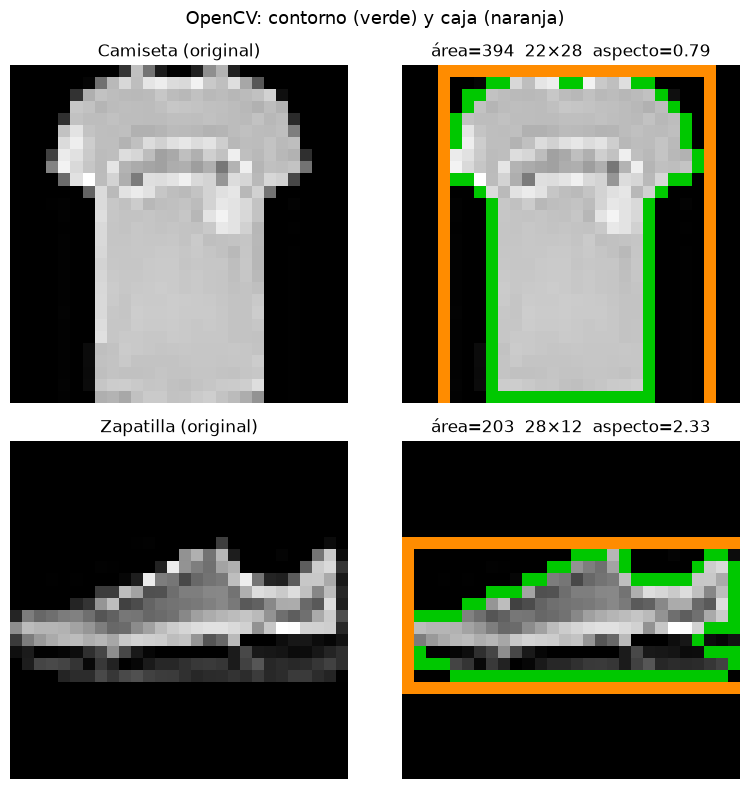

Camiseta : {'area': 393.5, 'ancho': 22, 'alto': 28, 'aspecto': 0.7857142857142857}
Zapatilla: {'area': 203.0, 'ancho': 28, 'alto': 12, 'aspecto': 2.3333333333333335}


In [3]:
def binarizar(img, umbral=20):
    """Prenda en blanco (255) sobre fondo negro."""
    _, mascara = cv2.threshold(img, umbral, 255, cv2.THRESH_BINARY)
    return mascara


def contorno_principal(img):
    """Contorno de mayor área, o None."""
    mascara = binarizar(img)
    contornos, _ = cv2.findContours(
        mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contornos:
        return None
    return max(contornos, key=cv2.contourArea)


def medidas(img):
    """Área del contorno, caja y aspecto (ancho/alto)."""
    contorno = contorno_principal(img)
    if contorno is None:
        return {"area": 0.0, "ancho": 0, "alto": 0, "aspecto": 0.0}
    _x, _y, ancho, alto = cv2.boundingRect(contorno)
    return {
        "area": float(cv2.contourArea(contorno)),
        "ancho": int(ancho),
        "alto": int(alto),
        "aspecto": ancho / max(alto, 1),
    }


def dibujar_contorno(img):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    contorno = contorno_principal(img)
    if contorno is not None:
        cv2.drawContours(vis, [contorno], -1, (0, 200, 0), 1)
        x, y, w, h = cv2.boundingRect(contorno)
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 140, 255), 1)
    return vis


ejemplos = [
    (int(np.where(y_test == 0)[0][0]), "Camiseta"),
    (int(np.where(y_test == 7)[0][0]), "Zapatilla"),
]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, (idx, nombre) in enumerate(ejemplos):
    axes[row, 0].imshow(x_test[idx], cmap="gray")
    axes[row, 0].set_title(f"{nombre} (original)")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(cv2.cvtColor(dibujar_contorno(x_test[idx]), cv2.COLOR_BGR2RGB))
    m = medidas(x_test[idx])
    axes[row, 1].set_title(
        f"área={m['area']:.0f}  {m['ancho']}×{m['alto']}  aspecto={m['aspecto']:.2f}"
    )
    axes[row, 1].axis("off")
plt.suptitle("OpenCV: contorno (verde) y caja (naranja)", fontsize=13)
plt.tight_layout()
plt.show()

print("Camiseta :", medidas(x_test[ejemplos[0][0]]))
print("Zapatilla:", medidas(x_test[ejemplos[1][0]]))


**Resultado**: La camiseta suele ser más alta que ancha; la zapatilla, al revés. El área y el aspecto cambian con la clase. Eso es una pista, no la solución: mídalo en más ejemplos.

Siguiente: el reto.


## Reto: ¿es calzado?

**Tarea**: Completar `es_calzado(img)` para que devuelva `True` en sandalia, zapatilla o bota, y `False` en el resto. Solo NumPy y OpenCV. **Prohibido** entrenar o usar `model.predict`.

**Enfoque**: El baseline de abajo usa el **brillo medio**. Es ingenuo y no llega a la meta.

Meta: **> 80%** de acierto en las 2,000 primeras imágenes de prueba (el 30% son calzado; decir siempre “no es calzado” da 70% y **no** cuenta como resolverlo).

Pistas (elige tú):

- `binarizar` + `medidas` del paso 3
- ¿el objeto es más ancho que alto?
- ¿el área es más chica que en una camiseta?
- combina dos reglas con `and` / `or`

Cambia el cuerpo de `es_calzado`, vuelve a ejecutar la celda de evaluación y mira si pasas del 80%.


**Código**:

Aciertos en 2000 imágenes de prueba: 42.8%
Meta del reto: > 80%
Aún no. Edita es_calzado, usa medidas() y vuelve a correr esta celda.


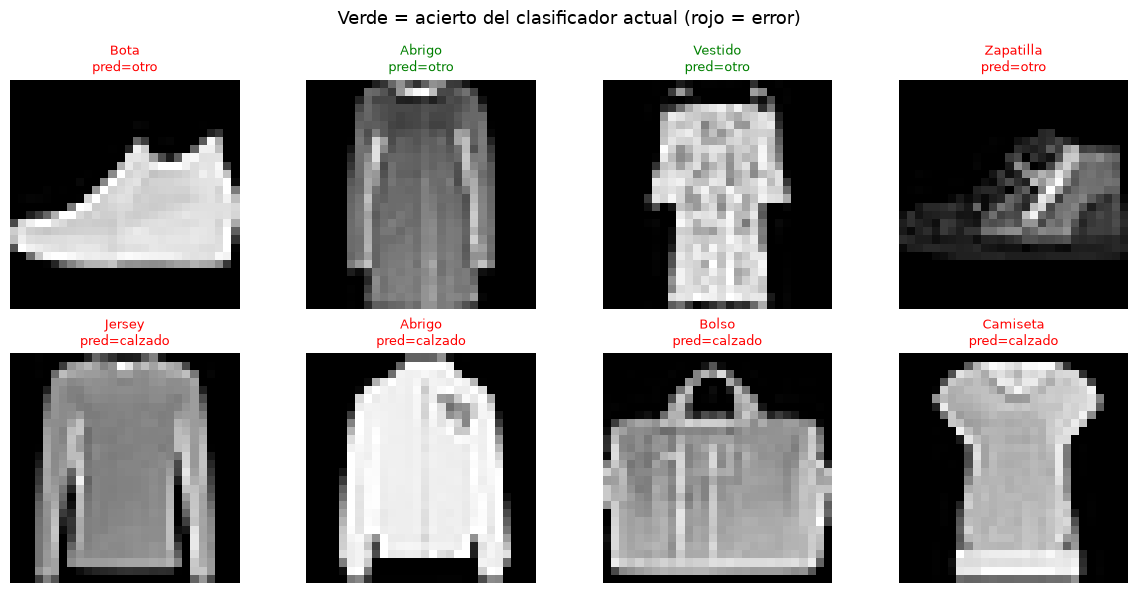

In [4]:
def es_calzado(img):
    """True si la prenda es sandalia, zapatilla o bota.

    Baseline ingenuo: brillo medio. Reemplázalo usando medidas().
    """
    return float(img.mean()) > 90


def evaluar(fn, n=2000):
    """Porcentaje de aciertos de `fn` en las primeras `n` imágenes de prueba."""
    aciertos = 0
    for i in range(n):
        predice_calzado = bool(fn(x_test[i]))
        es = int(y_test[i]) in CALZADO
        aciertos += int(predice_calzado == es)
    return 100.0 * aciertos / n


N = 2000
acc = evaluar(es_calzado, n=N)
print(f"Aciertos en {N} imágenes de prueba: {acc:.1f}%")
print("Meta del reto: > 80%")
if acc > 80:
    print("Meta alcanzada. ¿Puedes subir un poco más sin memorizar IDs?")
else:
    print("Aún no. Edita es_calzado, usa medidas() y vuelve a correr esta celda.")

# Muestra de 8 predicciones para depurar a ojo.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
rng = np.random.default_rng(0)
indices = rng.choice(N, size=8, replace=False)
for ax, idx in zip(axes.flat, indices):
    pred = es_calzado(x_test[idx])
    real = int(y_test[idx]) in CALZADO
    ax.imshow(x_test[idx], cmap="gray")
    color = "green" if pred == real else "red"
    ax.set_title(
        f"{NOMBRES[y_test[idx]]}\npred={'calzado' if pred else 'otro'}",
        color=color,
        fontsize=9,
    )
    ax.axis("off")
plt.suptitle("Verde = acierto del clasificador actual (rojo = error)", fontsize=13)
plt.tight_layout()
plt.show()


**Resultado**: El baseline de brillo medio se queda en **42.8%** en esta corrida, lejos del 80%. Ese número es el punto de partida, no la nota final: la nota es lo que obtengas tú al editar `es_calzado`.


## Cierre de la Parte 4 (y del taller)

Fashion-MNIST es un catálogo abierto de ropa. OpenCV mide forma. El reto es **tu** regla, no una red nueva.

### Qué se espera que hagas
1. Entender umbral + contorno + caja
2. Sustituir el brillo medio por una regla de forma
3. Pasar de 80% en las 2,000 de prueba

### Cómo encaja en el taller

| | Parte 1 | Parte 2 | Parte 3 | Parte 4 (esta) |
|---|---|---|---|---|
| Pregunta | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? |
| Respuesta | un dígito | un texto (SKU) | un ID de estación | calzado o no |
| Herramienta | red que aprendiste + `cv2.dnn` | decoder QR | detector ArUco | **tu** regla OpenCV |
| Dónde se usa | patrón sucio | apps | robots | catálogo / moda |

### Extra (opcional)

Las 10 clases con el MLP de la Parte 1: cambia `mnist` por `fashion_mnist` y las etiquetas por `NOMBRES`. Eso ya no es el reto; es comparar “forma a mano” vs “red que aprende”.
